# Conditional GAN for Handwritten Digit Generation in PyTorch

This notebook trains a **conditional Generative Adversarial Network (cGAN)** on MNIST so you can generate a requested handwritten digit from `0` through `9`.

A normal GAN learns to generate any realistic digit. A conditional GAN learns:

- "Generate something that looks real."
- "Also make it look like this specific label, such as digit `7`."

Real-life mental model: a student practices writing a requested digit, while a strict examiner checks both handwriting realism and whether the requested digit was followed.

## Goal

By the end, you will have a runnable PyTorch demo that:

1. Loads MNIST handwritten digit images.
2. Builds a conditional generator `G(z, y)` from scratch.
3. Builds a conditional discriminator `D(x, y)` from scratch.
4. Trains both models adversarially.
5. Generates images for a chosen digit label.

The model is intentionally compact so it can run on CPU, CUDA, or Apple Silicon MPS. For sharper digits, increase `EPOCHS` and train on the full dataset.

## Setup

This notebook requires PyTorch and torchvision:

```bash
python3 -m pip install torch torchvision
```

If your local Python version is too new for PyTorch wheels, use Python 3.10, 3.11, or 3.12 in a virtual environment.

In [1]:
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image

plt.style.use("seaborn-v0_8-whitegrid")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [2]:
def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = get_device()
DATA_DIR = Path("data/mnist")
OUTPUT_DIR = Path("outputs/digit_gan")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 28
IMAGE_CHANNELS = 1
NUM_CLASSES = 10
LATENT_DIM = 100
BATCH_SIZE = 128
EPOCHS = 5
LEARNING_RATE = 2e-4
BETA1 = 0.5

# Use a smaller subset for a fast demo. Set to None for all 60,000 MNIST images.
MAX_TRAIN_SAMPLES = 20_000

print(f"Using device: {DEVICE}")

Using device: cpu


## Conditional GAN Math

A normal GAN uses random noise `z`:

$$
\hat{x} = G(z)
$$

A conditional GAN also receives a label `y`:

$$
\hat{x} = G(z, y)
$$

The discriminator also receives the image-label pair:

$$
D(x, y) \rightarrow \text{probability that image } x \text{ is a real image of label } y
$$

The adversarial objective is:

$$
\min_G \max_D \; \mathbb{E}_{(x,y) \sim p_{data}}[\log D(x,y)] + \mathbb{E}_{z \sim p_z, y \sim p_y}[\log(1 - D(G(z,y),y))]
$$

In code, we use `BCEWithLogitsLoss`, which combines sigmoid plus binary cross-entropy in a numerically stable way.

For the discriminator:

$$
L_D = BCE(D(x,y), 1) + BCE(D(G(z,y),y), 0)
$$

For the generator:

$$
L_G = BCE(D(G(z,y),y), 1)
$$

The generator is rewarded when the discriminator believes generated images are real examples of the requested digit.

## Step 1: Load MNIST

MNIST images are grayscale `28 x 28` handwritten digits. The transform below maps pixel values from `[0, 1]` to `[-1, 1]`, matching the generator's final `tanh` activation.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,)),
])

train_dataset = datasets.MNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform,
)

if MAX_TRAIN_SAMPLES is not None:
    indices = torch.randperm(len(train_dataset))[:MAX_TRAIN_SAMPLES]
    train_dataset = Subset(train_dataset, indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
    drop_last=True,
)

print(f"Training images: {len(train_dataset):,}")
print(f"Batches per epoch: {len(train_loader):,}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.43MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.3MB/s]

Training images: 20,000
Batches per epoch: 156


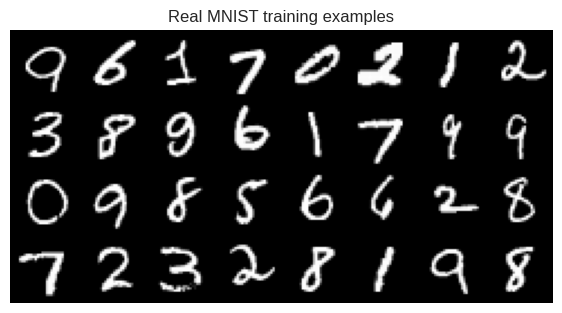

Labels: [9, 6, 1, 7, 0, 2, 1, 2, 3, 8, 9, 6, 1, 7, 9, 9, 0, 9, 8, 5, 6, 6, 2, 8, 7, 2, 3, 2, 8, 1, 9, 8]


In [4]:
def denormalize(images):
    return (images + 1.0) / 2.0

real_images, real_labels = next(iter(train_loader))
grid = make_grid(denormalize(real_images[:32]), nrow=8, padding=2)

plt.figure(figsize=(7, 4))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.title("Real MNIST training examples")
plt.axis("off")
plt.show()

print("Labels:", real_labels[:32].tolist())

## Step 2: Build the Conditional Generator

The generator receives:

- random noise `z`, shape `[batch, LATENT_DIM]`
- requested digit label `y`, shape `[batch]`

A label embedding converts `y` into a learnable vector. We concatenate noise and label embedding, project to a small feature map, then upsample to a `28 x 28` image.

In [5]:
class ConditionalGenerator(nn.Module):
    def __init__(self, latent_dim=100, num_classes=10, label_dim=10):
        super().__init__()
        self.label_embedding = nn.Embedding(num_classes, label_dim)
        self.project = nn.Sequential(
            nn.Linear(latent_dim + label_dim, 128 * 7 * 7),
            nn.BatchNorm1d(128 * 7 * 7),
            nn.ReLU(inplace=True),
        )
        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),
        )

    def forward(self, noise, labels):
        label_features = self.label_embedding(labels)
        x = torch.cat([noise, label_features], dim=1)
        x = self.project(x)
        x = x.view(x.size(0), 128, 7, 7)
        return self.upsample(x)

## Step 3: Build the Conditional Discriminator

The discriminator receives:

- image `x`, shape `[batch, 1, 28, 28]`
- label `y`, shape `[batch]`

The label is embedded into a full `28 x 28` label image and concatenated as a second channel. The discriminator then sees both the handwriting and the requested label.

In [6]:
class ConditionalDiscriminator(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.label_embedding = nn.Embedding(num_classes, IMAGE_SIZE * IMAGE_SIZE)
        self.features = nn.Sequential(
            nn.Conv2d(2, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
        )

    def forward(self, images, labels):
        label_map = self.label_embedding(labels).view(labels.size(0), 1, IMAGE_SIZE, IMAGE_SIZE)
        x = torch.cat([images, label_map], dim=1)
        x = self.features(x)
        return self.classifier(x)

## Step 4: Initialize Models

DCGAN-style initialization keeps early activations stable. Convolution and linear weights start near zero, and batch-normalization scale starts near one.

In [7]:
def weights_init(module):
    class_name = module.__class__.__name__
    if "Conv" in class_name or "Linear" in class_name:
        nn.init.normal_(module.weight.data, 0.0, 0.02)
        if getattr(module, "bias", None) is not None:
            nn.init.zeros_(module.bias.data)
    elif "BatchNorm" in class_name:
        nn.init.normal_(module.weight.data, 1.0, 0.02)
        nn.init.zeros_(module.bias.data)

generator = ConditionalGenerator(LATENT_DIM, NUM_CLASSES).to(DEVICE)
discriminator = ConditionalDiscriminator(NUM_CLASSES).to(DEVICE)
generator.apply(weights_init)
discriminator.apply(weights_init)

criterion = nn.BCEWithLogitsLoss()
optimizer_g = torch.optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=(BETA1, 0.999))
optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(BETA1, 0.999))

test_noise = torch.randn(4, LATENT_DIM, device=DEVICE)
test_labels = torch.tensor([0, 1, 2, 3], device=DEVICE)
test_images = generator(test_noise, test_labels)
test_logits = discriminator(test_images, test_labels)

assert test_images.shape == (4, 1, 28, 28)
assert test_logits.shape == (4, 1)
print("Shape checks passed.")

Shape checks passed.


## Step 5: Training Helpers

The fixed sample grid uses the same noise and labels after every epoch. That makes progress easier to compare because changes come from the model, not from a new random input.

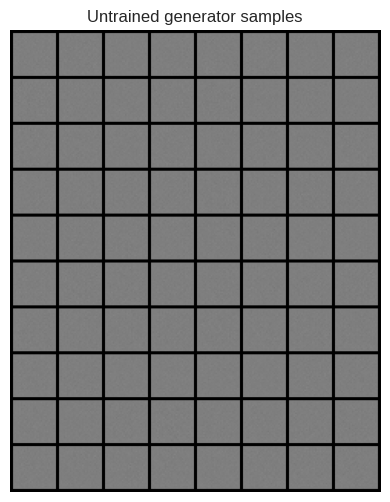

tensor([[[[ 1.6626e-04, -8.3466e-03, -2.7323e-03,  ..., -3.9359e-03,
           -7.4052e-03,  6.6868e-04],
          [ 9.8972e-03, -2.4613e-02, -3.3264e-03,  ..., -3.3541e-02,
           -6.7583e-03, -5.3292e-03],
          [ 1.0427e-02, -2.6446e-02, -1.3175e-02,  ..., -3.2411e-03,
           -1.3332e-02,  2.2898e-03],
          ...,
          [ 5.4484e-03, -4.6463e-03, -7.8722e-03,  ..., -2.2508e-02,
            2.7232e-03,  5.0122e-03],
          [-4.2133e-03, -3.1841e-03, -1.2765e-02,  ..., -4.2261e-03,
           -1.3763e-02, -5.2146e-03],
          [-1.9057e-03,  5.0794e-03, -2.7211e-03,  ..., -3.0126e-03,
           -9.9143e-03,  1.4260e-03]]],


        [[[ 9.1895e-04,  7.9378e-04,  4.2231e-03,  ..., -2.9979e-03,
           -2.7491e-03,  4.7341e-03],
          [ 6.0575e-03, -9.9431e-03, -7.5813e-04,  ..., -2.3650e-02,
           -1.7033e-02, -3.3395e-03],
          [ 4.7476e-03, -1.1599e-02,  2.6707e-03,  ..., -3.4574e-02,
           -1.5824e-02,  3.6327e-03],
          ...,
   

In [8]:
fixed_labels = torch.arange(0, NUM_CLASSES, device=DEVICE).repeat_interleave(8)
fixed_noise = torch.randn(fixed_labels.size(0), LATENT_DIM, device=DEVICE)

def show_generated_grid(model, noise, labels, title):
    model.eval()
    with torch.no_grad():
        images = model(noise, labels).detach().cpu()
    model.train()

    grid = make_grid(denormalize(images), nrow=8, padding=2)
    plt.figure(figsize=(8, 6))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()
    return images

show_generated_grid(generator, fixed_noise, fixed_labels, "Untrained generator samples")

## Step 6: Train the cGAN

Each batch has two updates.

**Discriminator update**

1. Score real `(image, label)` pairs as real.
2. Generate fake images from `(noise, label)`.
3. Score fake `(generated image, label)` pairs as fake.

**Generator update**

1. Generate fake images from `(noise, label)`.
2. Ask the discriminator to score them.
3. Update the generator so those scores move toward real.

The discriminator uses light one-sided label smoothing: real labels are `0.9` instead of `1.0`. This can reduce overconfidence early in training.

Epoch 01/5 | D loss: 0.639 | G loss: 2.606 | D(real): 0.827 | D(fake): 0.068


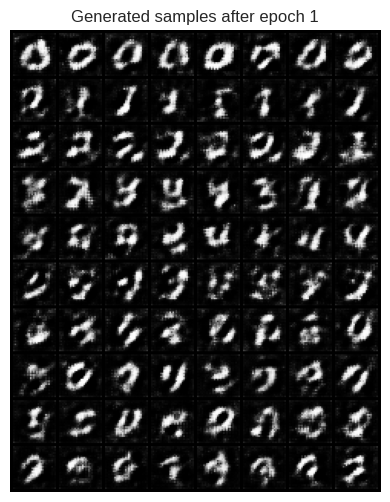

Epoch 02/5 | D loss: 0.909 | G loss: 1.543 | D(real): 0.697 | D(fake): 0.199


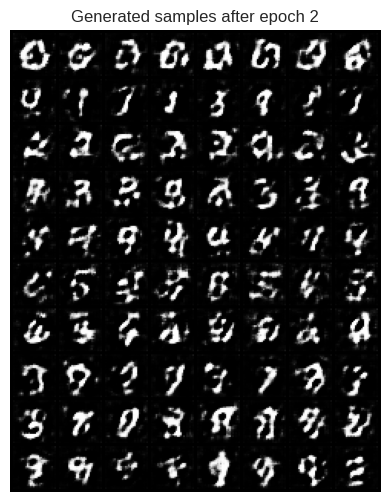

Epoch 03/5 | D loss: 1.017 | G loss: 1.330 | D(real): 0.636 | D(fake): 0.252


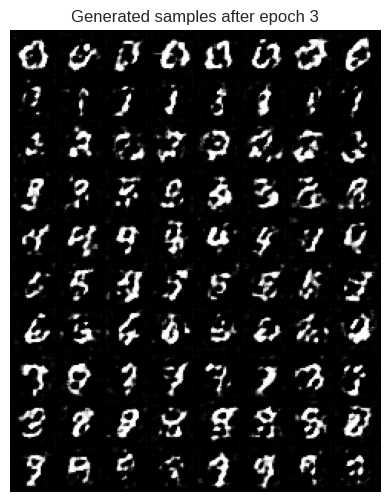

Epoch 04/5 | D loss: 1.038 | G loss: 1.389 | D(real): 0.660 | D(fake): 0.238


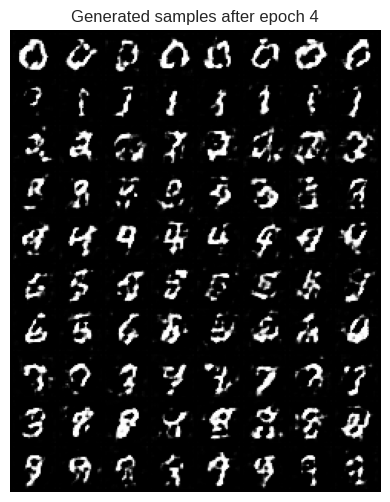

Epoch 05/5 | D loss: 0.973 | G loss: 1.069 | D(real): 0.570 | D(fake): 0.337


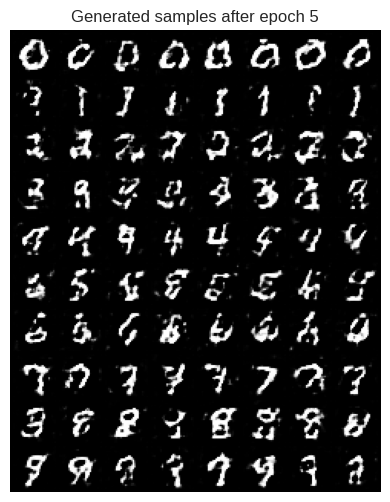

Saved models and sample images to: /content/outputs/digit_gan


In [9]:
history = {"d_loss": [], "g_loss": [], "d_real": [], "d_fake": []}

for epoch in range(1, EPOCHS + 1):
    for batch_index, (real_images, labels) in enumerate(train_loader, start=1):
        real_images = real_images.to(DEVICE)
        labels = labels.to(DEVICE)
        current_batch_size = real_images.size(0)

        real_targets = torch.full((current_batch_size, 1), 0.9, device=DEVICE)
        fake_targets = torch.zeros(current_batch_size, 1, device=DEVICE)

        # Train discriminator.
        optimizer_d.zero_grad(set_to_none=True)
        real_logits = discriminator(real_images, labels)
        d_real_loss = criterion(real_logits, real_targets)

        noise = torch.randn(current_batch_size, LATENT_DIM, device=DEVICE)
        fake_images = generator(noise, labels)
        fake_logits = discriminator(fake_images.detach(), labels)
        d_fake_loss = criterion(fake_logits, fake_targets)

        d_loss = d_real_loss + d_fake_loss
        d_loss.backward()
        optimizer_d.step()

        # Train generator.
        optimizer_g.zero_grad(set_to_none=True)
        noise = torch.randn(current_batch_size, LATENT_DIM, device=DEVICE)
        fake_images = generator(noise, labels)
        fake_logits = discriminator(fake_images, labels)
        g_loss = criterion(fake_logits, real_targets)
        g_loss.backward()
        optimizer_g.step()

        history["d_loss"].append(float(d_loss.item()))
        history["g_loss"].append(float(g_loss.item()))
        history["d_real"].append(float(torch.sigmoid(real_logits).mean().item()))
        history["d_fake"].append(float(torch.sigmoid(fake_logits).mean().item()))

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"D loss: {history['d_loss'][-1]:.3f} | "
        f"G loss: {history['g_loss'][-1]:.3f} | "
        f"D(real): {history['d_real'][-1]:.3f} | "
        f"D(fake): {history['d_fake'][-1]:.3f}"
    )

    sample_images = show_generated_grid(generator, fixed_noise, fixed_labels, f"Generated samples after epoch {epoch}")
    save_image(denormalize(sample_images), OUTPUT_DIR / f"epoch_{epoch:02d}.png", nrow=8)

torch.save(generator.state_dict(), OUTPUT_DIR / "conditional_generator.pt")
torch.save(discriminator.state_dict(), OUTPUT_DIR / "conditional_discriminator.pt")
print(f"Saved models and sample images to: {OUTPUT_DIR.resolve()}")

## Step 7: Read Training Curves

GAN losses can move up and down because both networks learn at the same time. Use the curves as a health signal, not as a simple "lower is always better" metric.

Useful signs:

- `D(real)` should usually be higher than `D(fake)` early in training.
- If `D(fake)` becomes very close to `0`, the discriminator may be too strong.
- If generated images all look the same, the generator may have mode collapse.
- Visual samples matter more than a single loss value.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["d_loss"], label="Discriminator loss", color="#7A3E3E")
axes[0].plot(history["g_loss"], label="Generator loss", color="#2E5C8A")
axes[0].set_title("GAN losses")
axes[0].set_xlabel("Batch update")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history["d_real"], label="Mean D(real)", color="#2F6B5F")
axes[1].plot(history["d_fake"], label="Mean D(fake)", color="#C06C3E")
axes[1].axhline(0.5, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Discriminator probabilities")
axes[1].set_xlabel("Batch update")
axes[1].set_ylabel("Probability real")
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 8: Generate a Specific Digit

This helper asks the trained generator to write one digit many different ways. Change `digit_to_generate` to any value from `0` through `9`.

In [ ]:
def generate_digit(model, digit, count=32):
    if not 0 <= int(digit) <= 9:
        raise ValueError("digit must be an integer from 0 through 9")

    model.eval()
    labels = torch.full((count,), int(digit), dtype=torch.long, device=DEVICE)
    noise = torch.randn(count, LATENT_DIM, device=DEVICE)
    with torch.no_grad():
        images = model(noise, labels).detach().cpu()
    model.train()
    return images

digit_to_generate = 7
generated_digit_images = generate_digit(generator, digit_to_generate, count=32)
grid = make_grid(denormalize(generated_digit_images), nrow=8, padding=2)

plt.figure(figsize=(7, 4))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.title(f"Generated handwritten digit {digit_to_generate}")
plt.axis("off")
plt.show()

save_image(denormalize(generated_digit_images), OUTPUT_DIR / f"generated_digit_{digit_to_generate}.png", nrow=8)

## Checks

Before trusting the results, inspect these points:

1. Generated images should become less noisy after each epoch.
2. Rows in the fixed grid should roughly match the requested digit labels.
3. The helper `generate_digit(generator, 7)` should mostly produce shapes that look like `7`.
4. If samples are blurry, train longer or use the full MNIST dataset.
5. If every image looks almost identical, reduce discriminator strength, lower learning rate, or train for more epochs.

A compact cGAN can create recognizable MNIST digits, but it will not match the quality of larger diffusion models or modern image generators.

In [ ]:
check_images = generate_digit(generator, 3, count=8)
assert check_images.shape == (8, 1, 28, 28)
assert torch.isfinite(check_images).all()
assert check_images.min() >= -1.05 and check_images.max() <= 1.05
print("Generated image checks passed.")

## Next Steps

Ways to improve this demo:

1. Set `MAX_TRAIN_SAMPLES = None` and increase `EPOCHS` to `20` or more.
2. Add dropout or spectral normalization to the discriminator.
3. Try a Wasserstein GAN with gradient penalty for more stable training.
4. Replace MNIST with Fashion-MNIST to generate clothing thumbnails.
5. Save generated images after every epoch and turn them into a GIF to watch the generator learn.

Core idea: the label tells the generator what to write, and the discriminator teaches whether the written digit looks real for that label.